# Introduction to MICrONS Data Access

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AllenInstitute/connectomics_at_cosyne/blob/main/examples/Cosyne_Data_Access.ipynb)


<b> Electron Microscopy (EM) enables morphological reconstruction of neurons and detection of their synaptic connectivity </b>. The <a href=https://www.microns-explorer.org/cortical-mm3>MICrONS dataset </a> is one of the largest datasets volume EM datasets currently available, and spans all layers of visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex. 
    
<em> Note on data access: </em> To make our lifes easier, we already queried the most of the data needed for this exercise from the database. We have made it available as versioned files that can be read with pandas. The entire dataset is hosted using the <a href=https://caveconnectome.github.io/sections/cave_overview.html> Connectome Annotation Versioning Engine (CAVE) </a>. A separate `preprocessing` notebook shows how to use CAVE to generate the files used in this notebook. 

In [1]:
from os.path import join as pjoin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
materialization_version = 1718 # Current public as of March 2026
data_url = "/Users/quanwen/Documents/GitHub/connectomics_at_cosyne/docs/resources/data"

## Visualize axon-proofread cells in the dataset

About the cell info table. The CAVE view that incorporates this information into a single view is: `aibs_cell_info`.

In [3]:
# Load the curated cell types table
cell_types_df = pd.read_csv(pjoin(data_url, f'v{materialization_version}_cell_info.csv'))

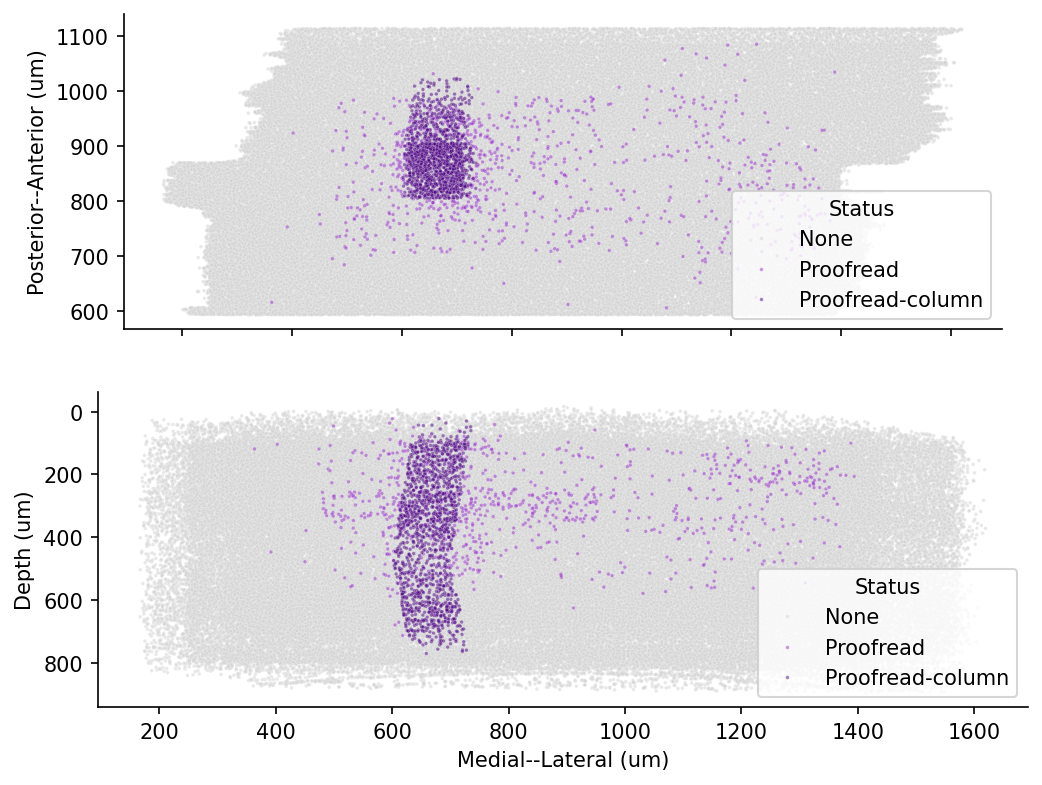

In [4]:
# @title Figure 1: Spatial position of neurons in MICrONS

fig, ax = plt.subplots(2,1, figsize=(8, 6),dpi=150, sharex=True)

# Added a labeled column for ease of plotting
cell_types_df['Status'] = 'None'
cell_types_df.loc[cell_types_df.status_axon, 'Status'] = 'Proofread'
cell_types_df.loc[cell_types_df.is_column, 'Status'] = 'Proofread-column'
cell_types_df = cell_types_df.sort_values('Status')

# Plot xz-view (top down)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_z_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'], 
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[0]
               )
# Plot xy-view (coronal)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_y_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'], 
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[1]
               )

sns.despine()
ax[1].invert_yaxis()
ax[0].set(xlabel='Medial--Lateral (um)', ylabel='Posterior--Anterior (um)')
ax[1].set(xlabel='Medial--Lateral (um)', ylabel='Depth (um)')
ax[0].set_aspect("equal")

### Transformed coordinate system

A note on the coordinate system: the MICrONS raw data has a  roughly 5 degree slope from the left to the right. Second, if you look at the location of the pia surface, it’s at around y = 0.4 * 10^6.

Not only are these units large, the offset is arbitrary and it would make much more sense to anchor y=0 to the pial surface.

For the soma location in the cell type data above, we have applied the `standard_transform`. For documentation, see [Standard Transform](https://github.com/ceesem/standard_transform). In general, there are three types of coordinates you may encounter and it is worth being deliberate in which system you use.

1. <b>Voxel coordinates</b> are the coordinates of a point in the original image volume. These are the coordinates that are used to index into the volumes you can see in Neuroglancer, but each number has a potentially different unit. In the MICrONs data, a voxel is 4 nm wide in the x and y directions, and 40 nm long in the z direction. This means that a 1x1x1 micron cube would be represented by a 250x250x25 voxel span. Annotations (such as synapses) are stored in voxel coordinates.
2. <b>Nanometer coordinates</b> are the coordinates of a point in the original image volume, but in nanometers. This is equivalent to the voxel coordinate multiplied by the voxel resolution, with no further transformation applied. Mesh and skeleton vertices are stored in nanometer coordinates.
3. <b>Transformed coordinates</b> reflect a trasnsformation that has been applied to the original image volume. This transformation is a rotation to make the pia surface as flat as possible, a translation to move the pial surface to y=0, and a scaling to bring coordinates into microns. Transformed coordinates are convenient for more accurate computations of depth and the pia-to-white-matter axis, but are not stored by default. 

## Synapse information

There are <b>337 million synapses</b> in the MICrONS dataset.

We have collected all of the input and output synapses for the proofread cells in version 1718 (March 2026). If you are interested in working with this dataset in the future, we added a `preprocessing` notebook that shows how the data was queried.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons. A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them. 

<b> Here we will load all Proofread-to-Proofread connections within the V1 column, </b> a small subset of the dataset. 

In [5]:
column_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_v1_column_synapses.feather'))
column_synapses.shape

(146711, 6)

### Connectivity matrix

The synapses of neurons create a network of connections. One way of visualizing this connectivity is in a matrix. Pandas provides the `pivot_table` function that we can use to make a matrix out of the tabular synapse data. For now, we will limit ourselves to the synapses between the proofread-column neurons.
    

<i>Note:</i> Each synapses has a `size` value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question. For now we ignore both synapse `size` and synapse `count`, and treat connection strength as <b>binary: connected or not-connected</b>

In [6]:
# matrix of synapse counts
syn_mat_binary = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x) > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat_binary = syn_mat_binary.reindex(columns=np.array(syn_mat_binary.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat_binary)

Number of edges: 78928
Number of possible edges: 1836025
Fraction of possible edges: 0.0430


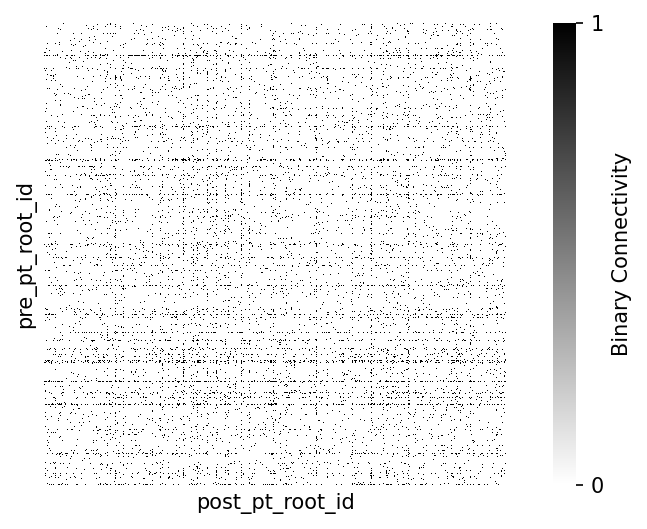

In [7]:
# @title Figure 2: Binary connectivity matrix (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_binary, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Binary Connectivity", "ticks": [0, 1]})


n_edges = len(row_indices)
n_possible_edges = syn_mat_binary.shape[0] * syn_mat_binary.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

<h4> Consider: different measures of synaptic strength </h4>

When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For 3 common ways of reporting connection strength:

<ol>
    <li> <b> Binary connectivity:</b> whether two cells are connected at all, as shown above.</li>
    <li> <b> Synaptic count:</b> the total number of synapses that are part of the connection. This is typical of the Fly connectome where <code>count</code> captures much of the connection diversity. The modal <code>count</code> in mouse cortex is much lower.</li>
    <li> <b> Synaptic size:</b> the size of the postsynaptic density at every connection, generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.</li>
    
</ol>

<p>How to take synapse size and number into account depends on the specific analysis. 


<i>Note:</i> The `size` reported in the MICrONS dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3d pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses). 

Let's consider synapse `count` first and seperately, using the same pivot table but with `aggfunc=lambda x: np.sum(x > 0)`:

### Synapse count

[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

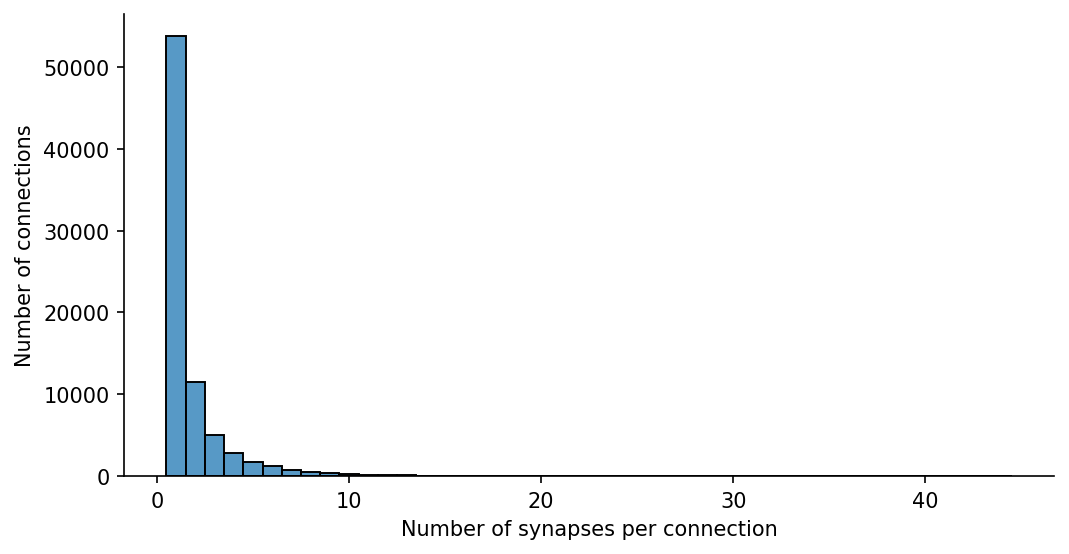

In [8]:
# @title Figure 3: Synapse count per connection

# Count Histogram on linear-x
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# Save connectivity matrix to CSV
syn_mat.to_csv(pjoin(data_url, "syn_mat.csv"))

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

In other systems than mouse cortex, the number of synapses might be the more important measure (see [Dorkenwald et al., 2022](https://elifesciences.org/articles/76120) for deeper dive into synapse size and counts). 

However, in mouse cortex the modal number of <b>Excitatory-to-excitatory connections is 1</b>, while inhibitory-excitatory connections may be more varied


In [9]:
# extract only the synapses between excitatory-excitatory cells in the column
excitatory_root_ids = cell_types_df.query("broad_type=='excitatory'").pt_root_id.to_numpy()

# Filter synapse table for excitatory-excitatory connections
exc_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(excitatory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]

np.shape(exc_exc_synapses)

(36233, 6)

In [10]:
# Filter synapse table for inhibitory-excitatory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]
np.shape(inh_exc_synapses)

(72765, 6)

[Text(0.5, 1.0, 'Inhibitory-Excitatory'), Text(0, 0.5, '')]

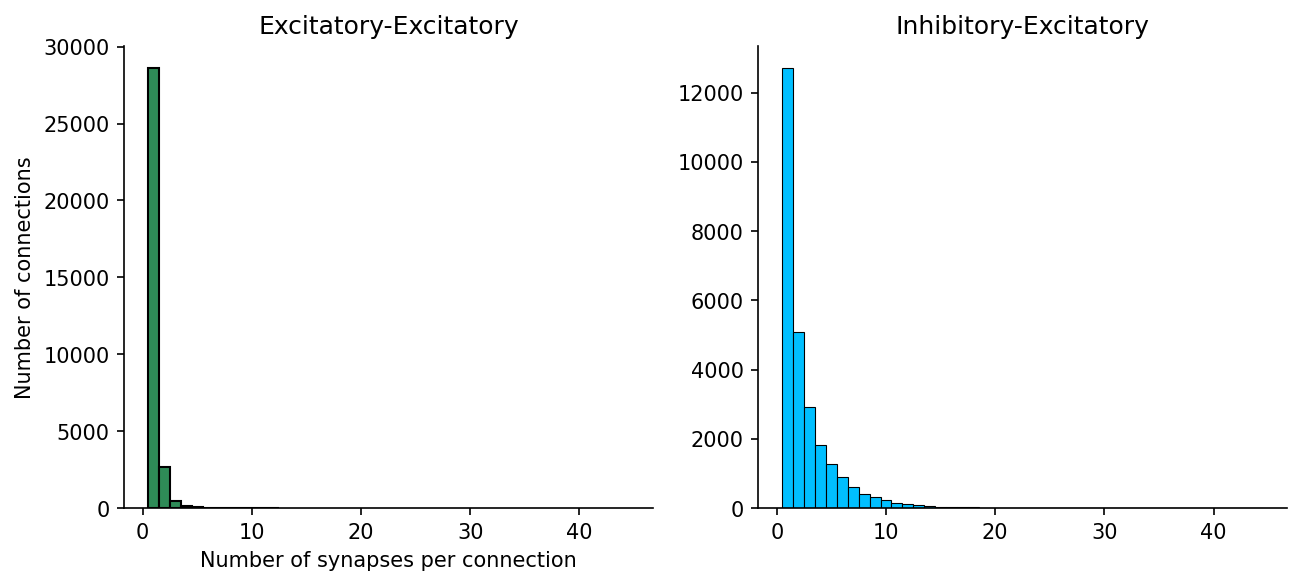

In [11]:
# @title Figure 4: Synapse count per connection differs for excitatory or inhibitory connections

fig, ax = plt.subplots(1,2, figsize=(10, 4),dpi=150, sharex=True)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[0],
    facecolor='seagreen',
)


syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
## This matrix cannot be quadratic
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[1],
    facecolor='deepskyblue',
)

sns.despine()
ax[0].set(title='Excitatory-Excitatory', xlabel="Number of synapses per connection", ylabel="Number of connections")
ax[1].set(title='Inhibitory-Excitatory', ylabel=None)

### Synapse Size

In mouse visual cortex, the diversity in <b>Excitatory to excitatory</b> connectivity is much more often in synaptic `size`:

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

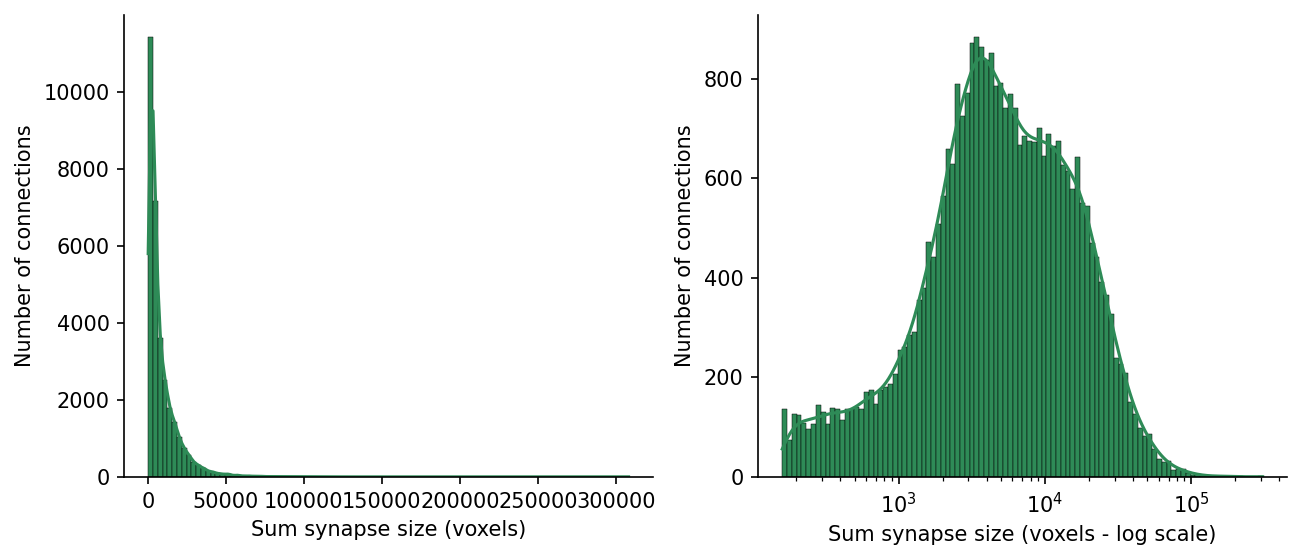

In [12]:
# @title Figure 5: Synapse size excitatory-to-excitatory connections

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")


Let's replot the <b>square matrix</b> with the log of the <code>sum</code> of synapses sizes between each connected pair `aggfunc=lambda x: np.log(np.sum(x))`

In [13]:
# matrix of log-summed synapse size
syn_mat_logsum = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat_logsum = syn_mat_logsum.reindex(columns=np.array(syn_mat.index)).astype(float)


Number of edges: 58840
Number of possible edges: 1611095
Fraction of possible edges: 0.0365


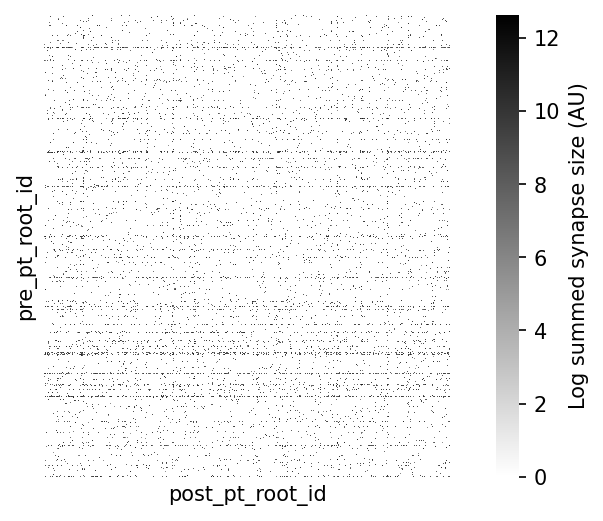

In [14]:
# @title Figure 6: Connectivity matrix, with synaptic strength (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_logsum, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log summed synapse size (AU)"})


row_indices, column_indices = np.nonzero(syn_mat_logsum)
n_edges = len(row_indices)
n_possible_edges = syn_mat_logsum.shape[0] * syn_mat_logsum.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

## Cell type tables

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time. 

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including: 

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>
    <li> Dendrite and spine multifeature model. The process of applying these labels is ongoing. </a> </li>
</ul>

Casey Schneider-Mizell's most recent cell typing, the multifeature cell typing, is available in CAVE from the <code>cell_type_multifeature_combo</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. These are colated in the `meso_type` column of our cell types dataframe. 

<b>For this demonstation, we will use `cell_types` from the perisomatic cell features</b>. Choose an alternate cell type classification at your discretion. 

*Note:* Cells here without a label are NaN. These are either non-neuronal cells or potential neurons with large segmentation errors that did not pass quality check

In [15]:
cell_types_df.value_counts(['cell_type']).sort_index()

cell_type
23P          19650
4P           14712
5P-ET         2149
5P-IT         7890
5P-NP          932
6P-CT         6770
6P-IT        11651
BC            3354
BPC           1494
MC            2469
NGC            588
OPC           1422
astrocyte     6898
microglia     2358
oligo         6901
pericyte       374
Name: count, dtype: int64

### Sorting the synapse matrix with cell types
    
Let's combine the synaptic connecitivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.  

In [16]:
# @title Helper function: sort_matrix_by_types
def sort_matrix_by_types(mat: pd.DataFrame, 
                         labels: pd.DataFrame, 
                         label_type_col: str = "cell_type_auto", 
                         label_id_col: str = "pt_root_id", 
                         post_labels: pd.DataFrame = None, 
                         post_label_type_col: str = None, 
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """
    
    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col
        
    mat_sorted = mat.copy()
    
    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [17]:
# Sort the column connectivity
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# sort the matrix by cell types to render sensibly in heatmap
cell_types_df = cell_types_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
syn_mat_ct, syn_mat_cell_types, _ = sort_matrix_by_types(syn_mat, cell_types_df, label_type_col="cell_type")

# Recover true synaptic sizes (exp of log values, preserving zeros for absent connections)
syn_mat_ct_true = syn_mat_ct.copy()
syn_mat_ct_true[syn_mat_ct_true != 0] = np.exp(syn_mat_ct_true[syn_mat_ct_true != 0])
syn_mat_ct_true.to_csv(pjoin(data_url, "syn_mat_ct.csv"))

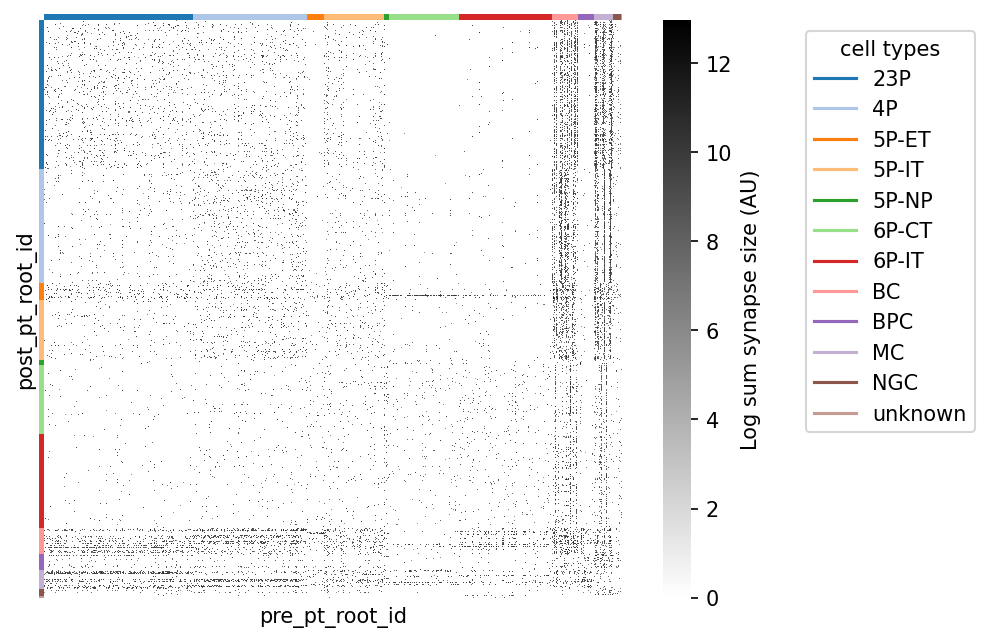

In [37]:
# @title Figure 7: Connectivity matrix sorted by cell type

# add colormap for cell type
cts, ct_idx = np.unique(syn_mat_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct.T, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log sum synapse size (AU)"})


# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

import matplotlib
# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")
plt.show()

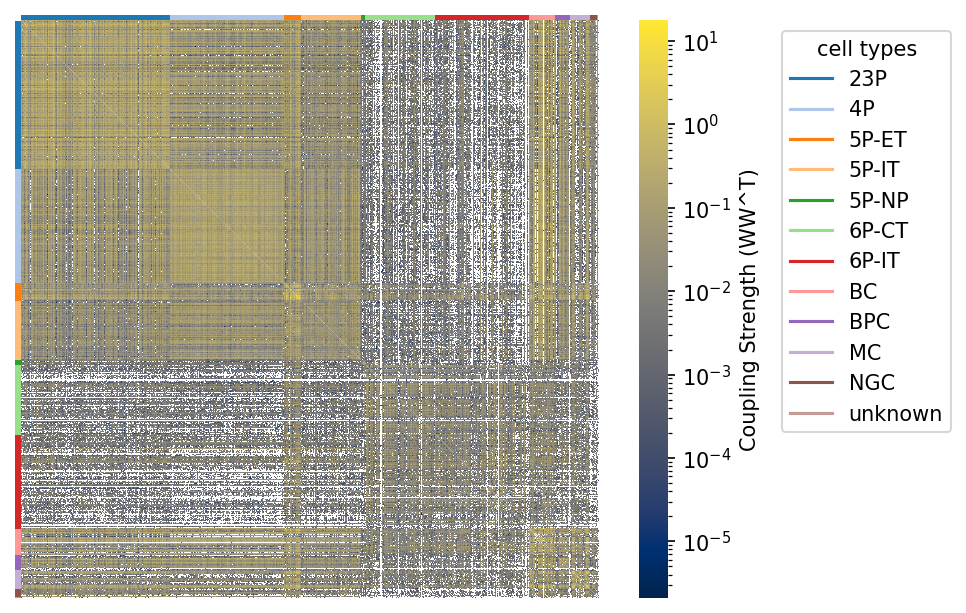

In [54]:
import matplotlib.colors as colors

Coupling = (syn_mat_ct_true.T @ syn_mat_ct_true)
N = Coupling.shape[0]
Coupling = Coupling / np.trace(Coupling) * N
#np.fill_diagonal(Coupling, 0)

data_masked = np.ma.masked_where(Coupling <= 0, Coupling)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# 4. Plot using imshow
# We use LogNorm to visualize the wide dynamic range of the coupling matrix

im = ax.imshow(
    data_masked,
    cmap="cividis",
    norm=colors.LogNorm(vmin=np.nanmin(data_masked), vmax=np.nanmax(data_masked)),
    aspect='equal',
    interpolation='nearest',
    rasterized=True
)

# 5. Styling
ax.set_facecolor('white')
ax.set_xticks([])                                          
ax.set_yticks([])
ax.axis('off')     

# 6. Add Colorbar
cb = fig.colorbar(im, ax=ax, label='Coupling Strength (WW^T)')
cb.outline.set_linewidth(0)

# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

import matplotlib
# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")

plt.show()

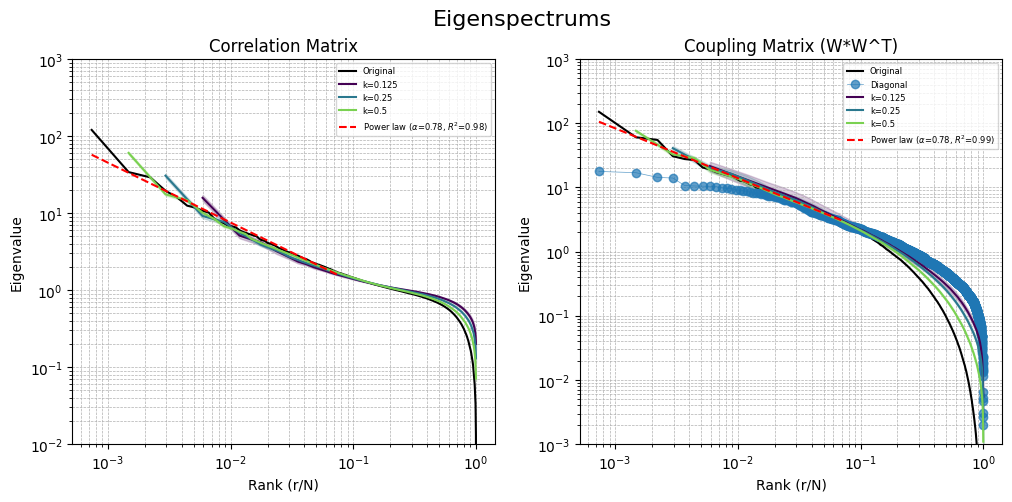

In [56]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "src"))
import subsampling

g = 0.7
CouplingMatrix = Coupling.to_numpy()
W0 = subsampling.generate_W_matrix(CouplingMatrix,g,seed=43)
#W = J.to_numpy() / (120.0 * N)
Correlation_Matrix = subsampling.compute_functional_connectivity(W0)
d = np.sqrt(np.diag(Correlation_Matrix))

# 2. Normalize covariance to get correlation: C_ij / (std_i * std_j)
#np.outer(d, d) #creates the matrix of std_i * std_j
Correlation_Matrix = Correlation_Matrix / np.outer(d, d)

# 3. (Optional) Ensure diagonal is exactly 1.0 to fix floating point errors
#np.fill_diagonal(Correlation_Matrix, 1.0)


evals = np.linalg.eigvalsh(Correlation_Matrix)
evals = np.sort(evals)[::-1]

fit_corr = subsampling.fit_power_law_eigenvalues(evals,100)

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
#ax[0].loglog(ranks_orig, np.sort(np.diag(Correlation_Matrix))[::-1],'o-', linewidth=1, alpha =0.5, label='Diagonal')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Correlation_Matrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax[0].loglog(fit_corr['data_x'], fit_corr['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_corr['exponent'], fit_corr['r_squared']))


ax[0].set_xlabel('Rank (r/N)')
ax[0].set_ylabel('Eigenvalue')
ax[0].set_ylim([10**-2, 10**3])
ax[0].legend(fontsize=6)
ax[0].set_title('Correlation Matrix')
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)



evals = np.linalg.eigvalsh(CouplingMatrix)
evals = np.sort(evals)[::-1]

fit_coupling = subsampling.fit_power_law_eigenvalues(evals,100)



ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
ax[1].loglog(ranks_orig, np.sort(np.diag(CouplingMatrix))[::-1],'o-', linewidth=0.5, alpha =0.7, label='Diagonal')


colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(CouplingMatrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax[1].loglog(fit_coupling['data_x'], fit_coupling['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_coupling['exponent'], fit_coupling['r_squared']))

ax[1].set_xlabel('Rank (r/N)')
ax[1].set_ylabel('Eigenvalue')
ax[1].set_ylim([10**-3, 10**3])
ax[1].legend(fontsize=6)
ax[1].set_title('Coupling Matrix (W*W^T)')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

#fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

## Beyond proofread-to-proofread connectivity

In the MICrONS dataset, the general rule is that dendrites onto cells with a cell body are sufficiently proofread to trust synaptic connections onto a cell. Axons on the other hand require so much proofreading that only ~2200 cells have proofread axons.

Proofreading status is available from CAVE table `proofreading_status_and_strategy`, and from the previously loaded cell types table.

In [19]:
cell_types_df.value_counts(['status_axon','strategy_axon'])

status_axon  strategy_axon          
False        none                       119826
True         axon_partially_extended      1576
             axon_fully_extended           518
             axon_interareal               120
Name: count, dtype: int64

Axon and dendrite compartment status are marked separately, as proofreading effort was applied differently to the different compartments in some cells.  In all cases, a status of `TRUE` indicates that false merges have been comprehensively removed, and the compartment is at least ‘clean’. Consult the ‘strategy’ column if completeness of the compartment is relevant to your  research.

Some cells were extended to different degrees of completeness, or with different research goals in mind. This is denoted by 'strategy_axon', which may be one of:

* `none`: No cleaning, and no extension, and status is `FALSE`.
* `axon_partially_extended`: The axon was extended outward from the soma, following each branch to its termination. Output synapses represent a sampling of potential partners.
* `axon_interareal`: The axon was extended with a preference for branches that projected to other brain areas. Some axon branches were fully extended, but local connections may be incomplete. Output synapses represent a sampling of potential partners.
* `axon_fully_extended`: Axon was extended outward from the soma, following each branch to its termination. After initial extension, every endpoint was identified, manually inspected, and extended again if possible. Output synapses represent a largely complete sampling of partners.

In [20]:
proofread_cells = cell_types_df.query('status_axon==True').pt_root_id.to_numpy()
print(f'Cells with proofread axons: {len(proofread_cells)}')

Cells with proofread axons: 2214


Previously we worked with the proofread cells among the V1 column, which totaled `146,711` unique synapses. However, the total number of <b>outputs from all proofread cells (including thalamic axons without somas in the volume) to any cell the volume </b> is much higher: `2,493,674` 


In [21]:
all_output_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_proofread_output_synapses.feather'))
print(f'All outputs from proofread neurons : {len(all_output_synapses)}')

neuron_ids = cell_types_df.query("(broad_type=='excitatory') | (broad_type=='inhibitory')").pt_root_id.to_numpy()
known_output_synapses = all_output_synapses.loc[all_output_synapses.post_pt_root_id.isin(neuron_ids)]
print(f'Synapses between known neurons (from proofread to any neuron): {len(known_output_synapses)}')

connection_counts = known_output_synapses.value_counts(['pre_pt_root_id','post_pt_root_id'])
print(f'Unique (binarized) connections between known neurons (from proofread to any neuron): {len(connection_counts)}')

All outputs from proofread neurons : 2493674
Synapses between known neurons (from proofread to any neuron): 2088830
Unique (binarized) connections between known neurons (from proofread to any neuron): 1257392


In [22]:
%%time
# Binarized connectivity for all synapses
rect_syn_mat = known_output_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x)>0)).fillna(0)
np.shape(rect_syn_mat)

CPU times: user 23.3 s, sys: 1.12 s, total: 24.4 s
Wall time: 24.5 s


(2275, 63718)

<b> Rendering synapses from proofread cells in MICrONS Minnie65: between V1 Column cells (gold) and between any cells (grey) </b>
    
<img src="https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/column_only_synapses.png" alt="synapses in column" align="left" style="width:500px;margin-right:10px;">
<img src="https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/column_and_all_synapses.png" alt="all synapses" align="left" style="width:500px;">
<p style="clear:both;">

# Part II: Adding context to connectivity

Here we will move beyond a curated excerpt of data prepared at a specific version, and provide an example of general data access patterns to Connectome Annotation Versioning Engine datastack for MICrONs.

1. CAVE access (microns, v1dd, flywire, fanc, banc, h01, etc.)
2. Linearized skeleton representation of neurons
3. Aysmmetric constraints on proofread inputs and outputs
4. Post synaptic struture: onto spine, shaft, soma
5. Topology of synapses along dendritic branches


## CAVE account setup 

<p>In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in <a href='https://www.nature.com/articles/s41592-024-02426-z'>more detail in the CAVE Paper</a>. 
    
<p>The MICrONS data is publicly available which means that no extra permissions need to be given to a new user account to access the data. Bulk downloads of some static data are also available without an account on <a href='https://microns-explorer.org/'> MICrONs Explorer</a>.

<b> A Google account (or Google-enabled account) is required to create a CAVE account. </b>

<p> Go to: <a href=https://global.daf-apis.com/auth/api/v1/user/token> https://global.daf-apis.com/auth/api/v1/user/token </a>to view a list of your existing tokens
<p> If you have never made a token before: 
<ol>
  <li>go here: <a href=https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept>https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept</a> to accept terms of service</li>
  <li>then go here <a href=https://global.daf-apis.com/auth/api/v1/create_token> https://global.daf-apis.com/auth/api/v1/create_token</a> to create a new token.</li>
</ol>

In [23]:
%%capture
!uv pip install caveclient
!uv pip install cloud-volume
!uv pip install ossify

In [58]:
from caveclient import CAVEclient

my_token = "ENTER YOUR TOKEN"
client = CAVEclient("minnie65_public", auth_token=my_token)
#client = CAVEclient('minnie65_public')


### Setup a persisent token for CAVE authentication
   
<p>If you are running this on your local machine rather than colab, you may also store the token on your machine. This makes future access easier as you do not have to specify the token.

```
client.auth.save_token(token=my_token, overwrite=True)

```

And thereafter initialize CAVE with:

```
client = CAVEclient("minnie65_public")
```

### Skeleton representation

Often in thinking about neurons, you want to measure things along a linear dimension of a neuron.

However, the segmentation and meshes are a full complex 3d shape that makes this non-trivial. There are methods for reducing the shape of a segmented neuron down to a linear tree like structure usually referred to as a skeleton. CAVE `Skeleton Service` automatically generates skeletons for a large number of cells in the dataset, and make the skeleton generation available on demand.

The python package `ossify` provides skeleton downloading, processing, analysis, and many convenience functions. Including loading cells directly from connectomics databases using CAVEclient. For documentation, see [Ossify](https://csdashm.com/ossify/)

Let's take one example proofread cell

In [59]:
import ossify

# Load basic cell (skeleton + L2 graph)
root_id = 864691135774053371 # known L23 cell at v1718
# root_id = proofread_cells[2] # consider iterating through proofread cells

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

Loaded cell 864691135774053371
Skeleton: 4893 vertices
Graph: 11542 L2 vertices


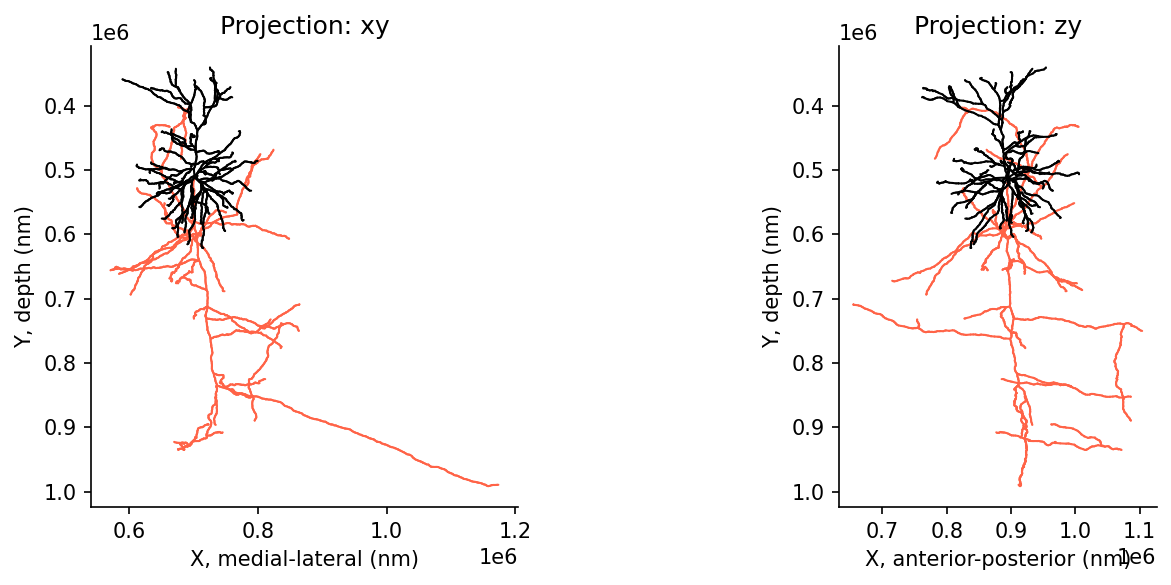

In [26]:
# @title Figure 8: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    ossify.plot.plot_morphology_2d(
        cell, 
        projection=proj, 
        color="compartment",
        palette={1: 'navy', 2: 'tomato', 3: 'black'}, # color scheme for axon, dendrite
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_ylabel(f"(nm)")
    axes[i].set_xlabel(f"(nm)")
    axes[i].set_aspect("equal")

axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='X, anterior-posterior (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.tight_layout()
plt.show()

<h4> Morphological compartment names </h4>

<p> The compartment types defined at each vertex adhere to standardized conventions for neuronal morphologies saved as swc files (for more information, see here: www.neuromorpho.org). </p>
    
These conventions are as follows:
<ul> 
    <li> 0 - undefined </li>
    <li> 1 - soma (default color 'olive') </li>
    <li> 2 - axon (default color 'steelblue') </li>
    <li> 3 - (basal) dendrite (default color 'firebrick' red) </li>
    <li> 4 - apical dendrite </li>
    <li> 5+ - custom </li>
</ul>

In most of these neurons, distinctions were not made between basal or apical dendrites - therefore dendrites should almost exclusively map to compartment type "3".

### Adding synapse positions to skeleton

In [27]:
# Load skeleton with synaptic features
root_id = 864691135774053371 # known L23 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

# All annotations in the cell  
cell.annotations.describe()

Loaded cell 864691135774053371
Skeleton: 4893 vertices
Graph: 11542 L2 vertices
# Annotations (2)
├── pre_syn (PointCloudLayer)
│   ├── 383 vertices
│   ├── features: [created, deleted, post_pt_position_x, post_pt_position_y, post_pt_position_z, post_pt_root_id, 
│       post_pt_supervoxel_id, pre_pt_l2_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
│   └── Links: graph <-> pre_syn
└── post_syn (PointCloudLayer)
    ├── 4794 vertices
    ├── features: [created, deleted, post_pt_l2_id, post_pt_position_x, post_pt_position_y, post_pt_position_z, 
│       post_pt_root_id, post_pt_supervoxel_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
    └── Links: graph <-> post_syn


In [28]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes
pre_syn_df.columns

Index(['created', 'deleted', 'pre_pt_position_x', 'pre_pt_position_y',
       'pre_pt_position_z', 'post_pt_position_x', 'post_pt_position_y',
       'post_pt_position_z', 'ctr_pt_position_x', 'ctr_pt_position_y',
       'ctr_pt_position_z', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id',
       'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_l2_id'],
      dtype='object')

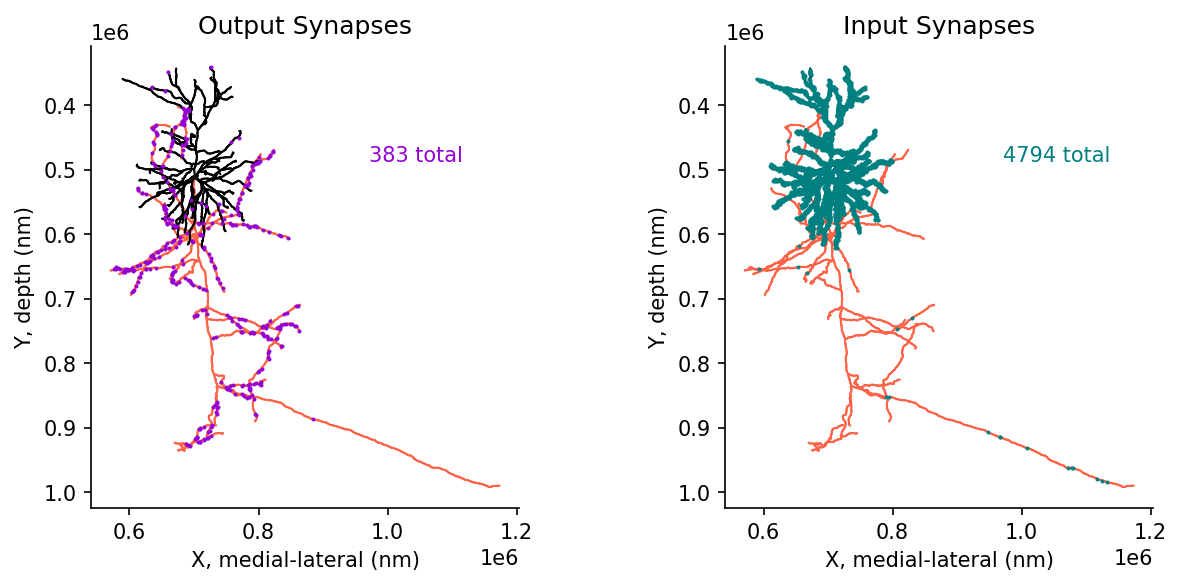

In [29]:
# @title Figure 9: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell, 
                                   projection="xy", 
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])

# Output synapses   
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100) 
ax[0].text(.65,.75,f'{len(pre_syn_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses   
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100) 
ax[1].text(.65,.75,f'{len(post_syn_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')

sns.despine()
plt.show()

#### Proofreading considerations for inputs vs outputs

In [30]:
# Filter output synapses to known postsynaptic cells
pre_syn_to_known_df = pre_syn_df.loc[pre_syn_df.post_pt_root_id.isin(cell_types_df.pt_root_id)]

# Filter input synapses from known postsynaptic cells
post_syn_from_known_df = post_syn_df.loc[post_syn_df.pre_pt_root_id.isin(cell_types_df.pt_root_id)]

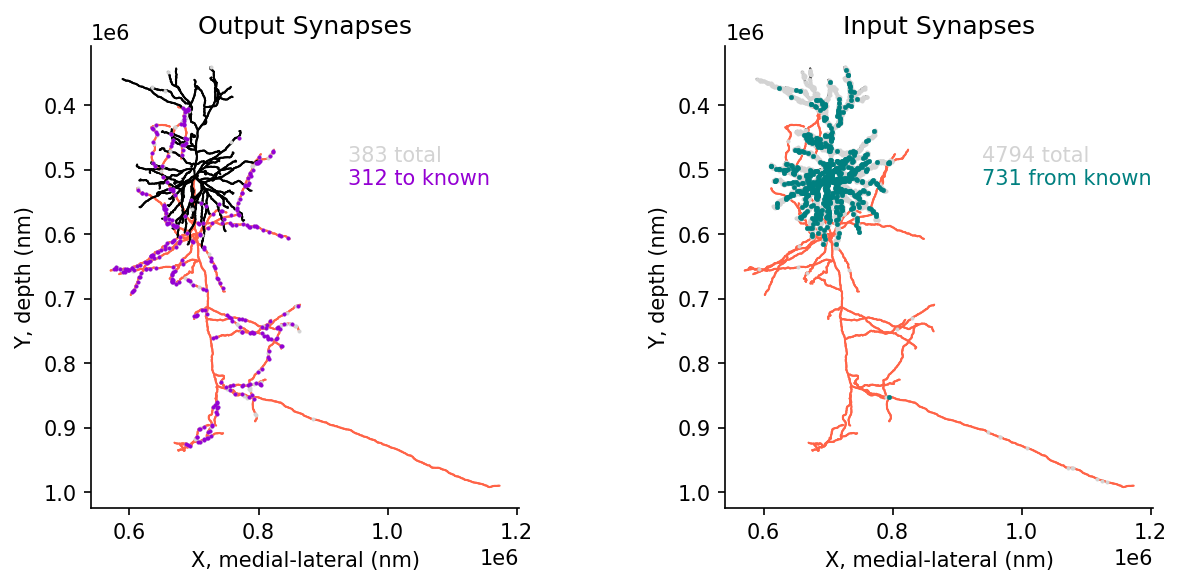

In [31]:
# @title Figure 10: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell, 
                                   projection="xy", 
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, color="lightgrey", ax=ax[0], edgecolor=None, zorder=100) 
sns.scatterplot(data=pre_syn_to_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100) 
ax[0].text(.6,.75,f'{len(pre_syn_df)} total', color='lightgrey',  transform = ax[0].transAxes)
ax[0].text(.6,.7,f'{len(pre_syn_to_known_df)} to known', color='darkviolet',  transform = ax[0].transAxes)

# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, color="lightgrey", ax=ax[1], edgecolor=None, zorder=100) 
sns.scatterplot(data=post_syn_from_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=5, color="teal", ax=ax[1], edgecolor=None, zorder=100) 
ax[1].text(.6,.75,f'{len(post_syn_df)} total', color='lightgrey',  transform = ax[1].transAxes)
ax[1].text(.6,.7,f'{len(post_syn_from_known_df)} from known', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

#### Synapse compartment classification

Up until now we have considered all synapses between any two cells, but different synapses target different compartments on the post synaptic cell. 

![](https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/sss-diagram.png)

Diagram and synapse compartment classification from: [A quantitative census of millions of postsynaptic structures in a large electron microscopy volume of mouse visual cortex (Pedigo et al.)](https://www.biorxiv.org/content/10.64898/2026.02.19.706834v1). 

Available as CAVE table: `synapse_target_predictions_ssa_v2`.


In [32]:
# Add spine information to outputs
output_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=pre_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   } 
).set_index('id')

pre_syn_df = (pre_syn_df.merge(output_synapse_tags, left_index=True, right_index=True, how='left')
              .rename(columns={'tag': 'Target'})
              .fillna({'Target': 'none'})
             )

# Add spine information to inputs
input_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=post_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   } 
).set_index('id')

post_syn_df = (post_syn_df.merge(input_synapse_tags, left_index=True, right_index=True, how='left')
               .rename(columns={'tag': 'Target'})
               .fillna({'Target': 'none'})
             )


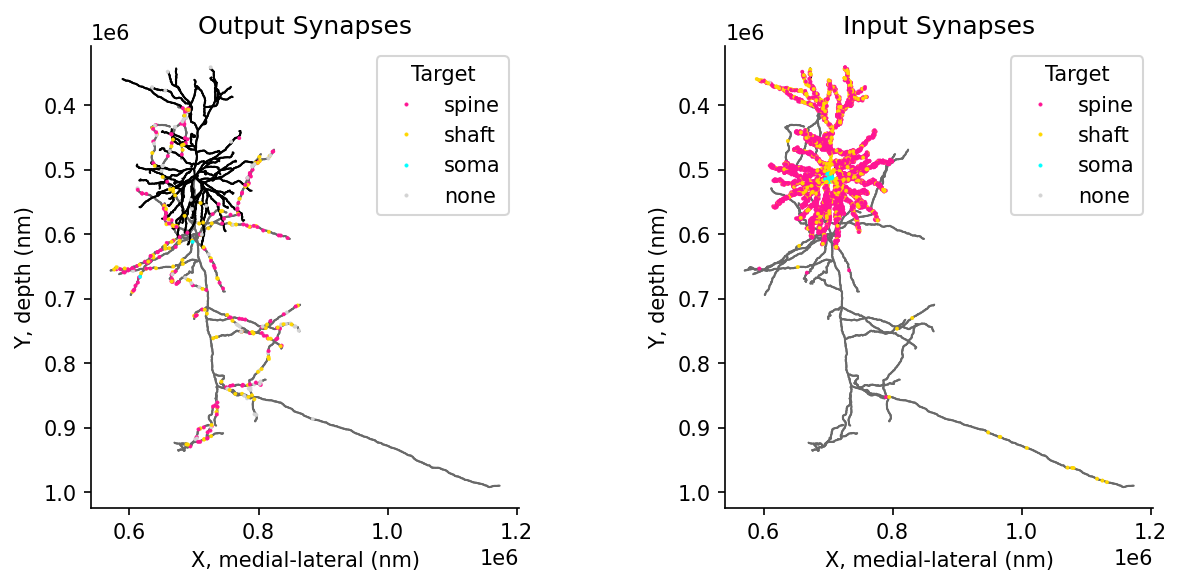

In [33]:
# @title Figure 11: Synaptic target compartments: spine, shaft, soma

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell, 
                                   projection="xy", 
                                   color="compartment",
                                   palette={1: 'navy', 2: 'dimgrey', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, hue='Target', hue_order=['spine','shaft','soma','none'], 
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'}, 
                ax=ax[0], edgecolor=None, zorder=100) 


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, hue='Target', hue_order=['spine','shaft','soma','none'], 
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'}, 
                ax=ax[1], edgecolor=None, zorder=100) 


ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

#### Filtering synapses by compartment and distance

In [34]:
### Calculate synapse distance to root

# Convert annotations to positional indices for algorithm
post_syn_indices = cell.annotations.post_syn.map_index_to_layer(
    "skeleton", as_positional=True
)
# compute distance to root for every annotation
distances_to_root = cell.skeleton.distance_to_root(post_syn_indices)      
post_syn_df['distance_to_root'] = distances_to_root


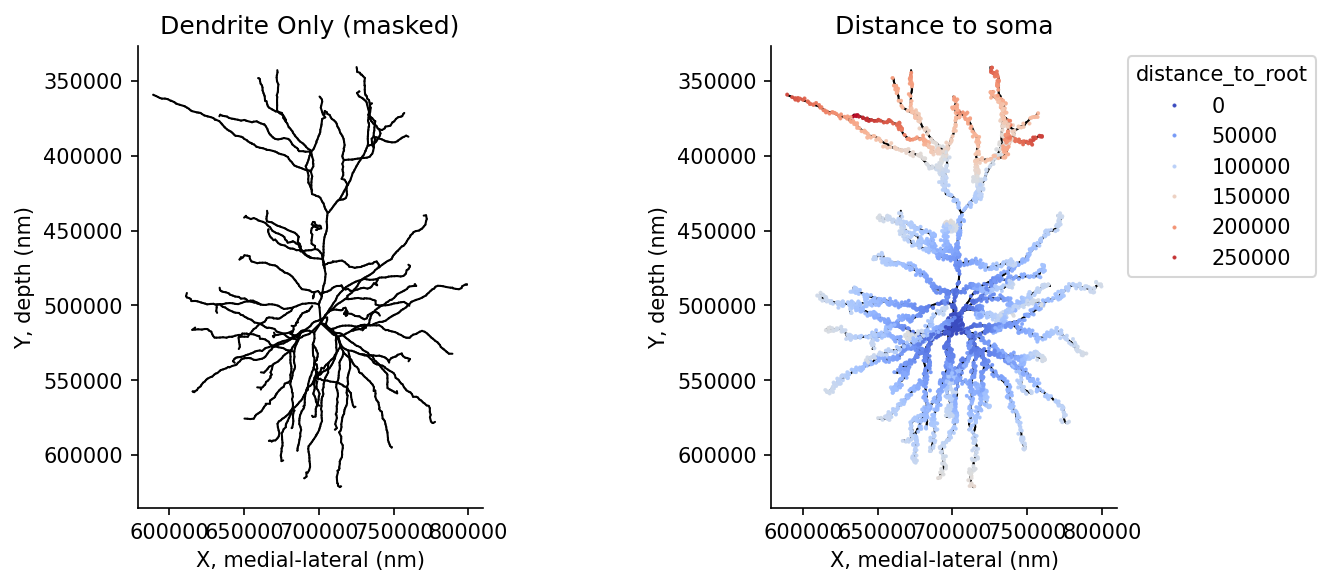

In [35]:
# @title Figure 12: Skeleton filtering and distance calculation

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

with cell.skeleton.mask_context(cell.skeleton.features['compartment'] != 2) as dendrite_cell:
    for i in range(2):
        ossify.plot.plot_morphology_2d(dendrite_cell, 
                                       projection="xy", 
                                       color="compartment",
                                       palette={1: 'navy', 2: 'dimgrey', 3: 'black'},
                                       ax=ax[i])

    dendrite_syn_ids= dendrite_cell.annotations.post_syn.nodes.index.to_numpy()



# Input synapses
sns.scatterplot(data=post_syn_df.loc[post_syn_df.index.isin(dendrite_syn_ids)],
                x="ctr_pt_position_x", y="ctr_pt_position_y", 
                s=3, hue='distance_to_root', palette= 'coolwarm',
                ax=ax[1], edgecolor=None, zorder=100)


ax[0].set(title="Dendrite Only (masked)", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Distance to soma", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))
plt.show()

# Further resources:

In the repository for this data access tutorial, there is also

* Preprocessing used to colate the cell types information : `preprocessing_celltypes_v1718.ipynb`
* Setting up a persistent CAVE token for continued use in google colab : `Tutorial_Colab_Persistent_Token.ipynb`
* Downloading the synaptic cleft and mesh around the synapse for further analysis : `Tutorial_Download_Synapse_Mesh.ipynb`
* Programmatic generation and parsing of neuroglancer states : `Tutorial_NGLUI.ipynb`

<b>Furter documentation</b>

* MICrONS Tutorials : [https://tutorial.microns-explorer.org/](https://tutorial.microns-explorer.org/)
* Connectome Annotation Versioning Engine CAVE : [https://www.caveconnecto.me/CAVEclient/tutorials/](https://www.caveconnecto.me/CAVEclient/tutorials/)
* Ossify : [https://csdashm.com/ossify/](https://csdashm.com/ossify/)